**Q2.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

 1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly skewed variables that require a log or arcsinh transformation) Note this is different than normalizing: there is a text below that explains further. Clean the data however you think is most appropriate.

In [2]:
# load in data
df = pd.read_csv("cars_hw.csv")
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Unnamed: 0         976 non-null    int64
 1   Make               976 non-null    str  
 2   Make_Year          976 non-null    int64
 3   Color              976 non-null    str  
 4   Body_Type          976 non-null    str  
 5   Mileage_Run        976 non-null    int64
 6   No_of_Owners       976 non-null    str  
 7   Seating_Capacity   976 non-null    int64
 8   Fuel_Type          976 non-null    str  
 9   Transmission       976 non-null    str  
 10  Transmission_Type  976 non-null    str  
 11  Price              976 non-null    int64
dtypes: int64(5), str(7)
memory usage: 91.6 KB


- change year to str
- Want to take the log of price since heavy right skew after looking at teh data rangler
- drop the unnames col casue uts just an index

In [4]:
df = df.drop(columns=["Unnamed: 0"])
df["Make_Year"] = df["Make_Year"].astype("str")
df['log_Price'] = np.log(df['Price'])
df['log_Mileage_Run'] = np.log(df['Mileage_Run'])

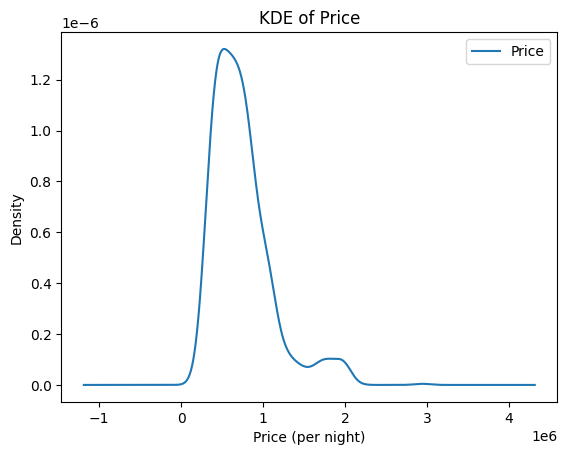

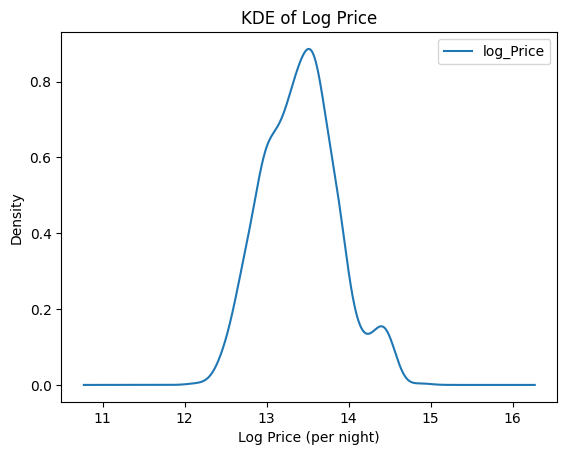

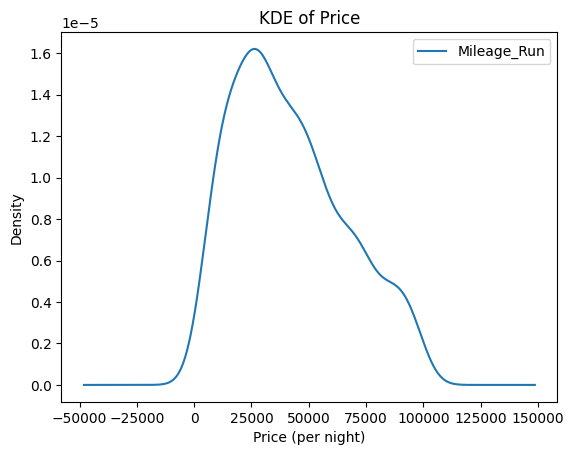

In [5]:
# KDE for price
df['Price'].plot.kde(legend=True)
plt.title('KDE of Price')
plt.xlabel('Price (per night)')
plt.show()


# Kernel density plot for log Price
df['log_Price'].plot.kde(legend=True)
plt.title('KDE of Log Price')
plt.xlabel('Log Price (per night)')
plt.show()

# KDE for price
df['Mileage_Run'].plot.kde(legend=True)
plt.title('KDE of Price')
plt.xlabel('Price (per night)')
plt.show()

In [6]:
categorical_cols = ['Make', 'Color', 'Body_Type', 'No_of_Owners', 'Fuel_Type', 'Transmission', 'Transmission_Type']
cat_dummies = pd.get_dummies(df[categorical_cols], drop_first=True, prefix=['Make', 'Color', 'Body_Type', 'No_of_Owners', 'Fuel_Type', 'Transmission', 'Transmission_Type'])
print(cat_dummies.head())

   Make_Datsun  Make_Ford  Make_Honda  Make_Hyundai  Make_Jeep  Make_Kia  \
0        False      False       False         False      False     False   
1        False      False       False          True      False     False   
2        False      False        True         False      False     False   
3        False      False       False         False      False     False   
4        False      False       False          True      False     False   

   Make_MG Motors  Make_Mahindra  Make_Maruti Suzuki  Make_Nissan  ...  \
0           False          False               False        False  ...   
1           False          False               False        False  ...   
2           False          False               False        False  ...   
3           False          False               False        False  ...   
4           False          False               False        False  ...   

   Body_Type_suv  No_of_Owners_2nd  No_of_Owners_3rd  Fuel_Type_petrol  \
0          False        

2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?

In [7]:
brand_price = df.groupby('Make')['log_Price']
print(brand_price.describe())

               count       mean       std        min        25%        50%  \
Make                                                                         
Chevrolet        6.0  12.919895  0.480975  12.495004  12.568392  12.752286   
Datsun           3.0  12.576047  0.036311  12.538967  12.558302  12.577636   
Ford            52.0  13.468280  0.210895  12.577636  13.361380  13.469493   
Honda           73.0  13.536318  0.336972  12.663497  13.272506  13.573439   
Hyundai        305.0  13.368511  0.398781  12.421184  13.091904  13.366094   
Jeep             4.0  14.216591  0.105084  14.070153  14.183270  14.240265   
Kia              8.0  14.292177  0.076877  14.129591  14.272242  14.303105   
MG Motors       35.0  14.439052  0.066263  14.278615  14.395744  14.429615   
Mahindra        18.0  13.898953  0.159906  13.587354  13.851808  13.905680   
Maruti Suzuki  293.0  13.218132  0.371409  12.375815  12.926348  13.174956   
Nissan           4.0  13.641194  0.392610  13.071070  13.537775 

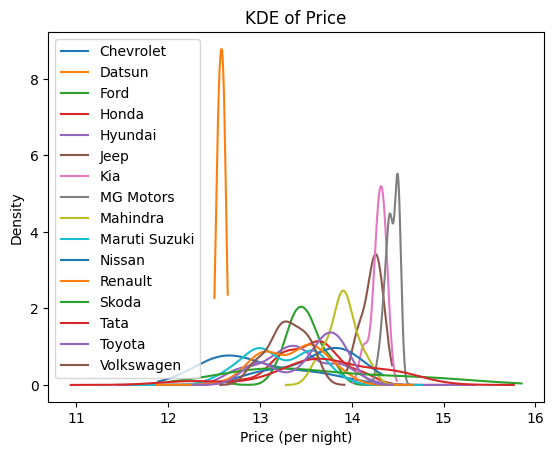

In [8]:
brand_price.plot.kde(legend=True)
plt.title('KDE of Price')
plt.xlabel('Price (per night)')
plt.show()

 3. Split the data into an 80% training set and a 20% testing set.

In [9]:
# Define X and y
X = df['log_Mileage_Run'] + cat_dummies
y = df['log_Price']

# splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?

5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?

6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.